In [3]:
import pandas as pd
import numpy as np

# P-value for 7/10

In [9]:
np.random.binomial(10, 0.5)

4

In [10]:
n = 10000
result = []
for i in range(n):
  np.random.seed(i)
  result.append(np.random.binomial(10, 0.5))

In [11]:
df = pd.DataFrame(result)

In [12]:
df

,0
0,5
1,5
2,5
3,5
4,8
...,...
9995,5
9996,6
9997,2
9998,4


In [13]:
# считаем отклонение
df['deviation'] = abs(df[0] - 5)

In [14]:
df

,0,deviation
0,5,0
1,5,0
2,5,0
3,5,0
4,8,3
...,...,...
9995,5,0
9996,6,1
9997,2,3
9998,4,1


In [19]:
# FPR
(df['deviation'] >= 2).mean()

np.float64(0.3515)

# P-value scale (шкала p-value)

In [20]:
deviations = [0,1,2,3,4,5]

In [29]:
result = []
for i in deviations:
  result.append((i, (df['deviation'] >= i).mean()))

In [30]:
pvals = pd.DataFrame(result, columns=['heads', 'p-values'])

In [31]:
pvals

,heads,p-values
0,0,1.0000
1,1,0.7573
2,2,0.3515
3,3,0.1124
4,4,0.0229
5,5,0.0009


# P-value for statisfaction case (p-value для удовлетворенности клиентов)

## P-value 84/115

In [32]:
sample_size = 115

In [35]:
n = 10000
result = []
for i in range(n):
  np.random.seed(i)
  result.append(np.random.binomial(sample_size, 0.8))

In [37]:
df = pd.DataFrame(result)

In [38]:
df

,0
0,92
1,93
2,93
3,92
4,84
...,...
9995,93
9996,90
9997,99
9998,96


In [40]:
sample_size * 0.8

92.0

In [41]:
df['deviation'] = df[0] - sample_size * 0.8

In [42]:
df

,0,deviation
0,92,0.0
1,93,1.0
2,93,1.0
3,92,0.0
4,84,-8.0
...,...,...
9995,93,1.0
9996,90,-2.0
9997,99,7.0
9998,96,4.0


In [51]:
# вычисляем отклонение
(df['deviation'] <= -8).mean()

np.float64(0.0437)

## Scale

In [56]:
# варианты отклонений
devs = list(range(0, int(sample_size * 0.8) + 1))

In [57]:
result = []
for i in devs:
  result.append((i, (df['deviation'] <= -i).mean()))

In [60]:
pvals = pd.DataFrame(result, columns=['people', 'p-values'])

In [61]:
pvals

,people,p-values
0,0,0.5348
1,1,0.4498
2,2,0.3632
3,3,0.2777
4,4,0.2067
...,...,...
88,88,0.0000
89,89,0.0000
90,90,0.0000
91,91,0.0000


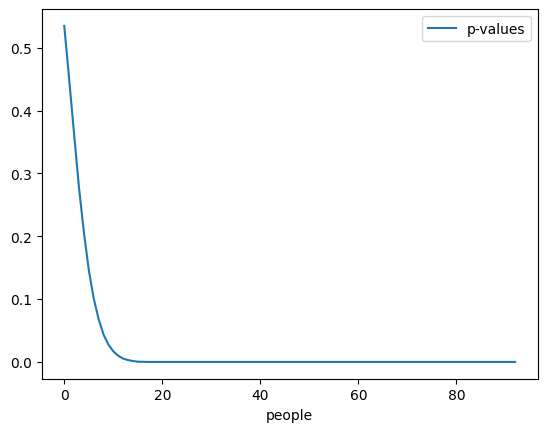

In [68]:
pvals.set_index('people').plot();

In [69]:
pvals.head(18)

,people,p-values
0,0,0.5348
1,1,0.4498
2,2,0.3632
3,3,0.2777
4,4,0.2067
5,5,0.1464
6,6,0.1013
7,7,0.0685
8,8,0.0437
9,9,0.0277


# P-value with statistical test

In [72]:
from statsmodels.stats.proportion import proportions_ztest

In [73]:
# вводим данны: кол-во удовлетворенных клиентов, кол-во клиентов, которых обзванивают
# удовлетворенность соответствующая нулевой гипотезе, в нашем случае 80% - 0.8
# альтернатива - в нашем случае односторонняя и в меньшую сторону
proportions_ztest(84, 115, 0.8, alternative='smaller')

(np.float64(-1.6811962678215244), np.float64(0.046362399106540116))

In [75]:
# scale
pvals['pval_ztest'] = pvals['people'].apply(lambda x:proportions_ztest(sample_size - x, 115, 0.8, alternative='smaller')[1])

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/weightstats.py:838: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = value / std


In [77]:
pvals

,people,p-values,pval_ztest
0,0,0.5348,0.500000
1,1,0.4498,0.409252
2,2,0.3632,0.325579
3,3,0.2777,0.251815
4,4,0.2067,0.189428
...,...,...,...
88,88,0.0000,0.000000
89,89,0.0000,0.000000
90,90,0.0000,0.000000
91,91,0.0000,0.000000


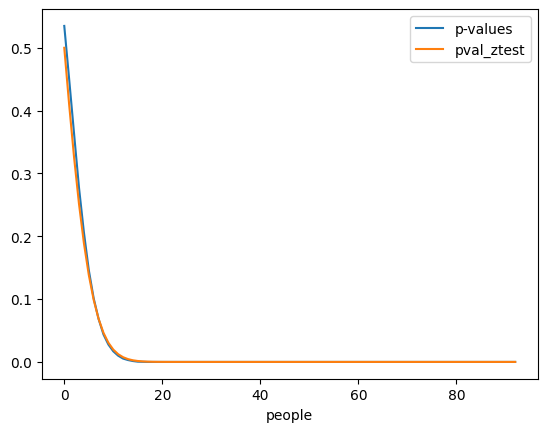

In [78]:
pvals.set_index('people').plot();